In [5]:
import os # Needed for the path funtions like join, basename ..
import sys # Needed to add the src folder to the hidden list of folder locations that Python searches through whenever an import statement is typed. If a folder isn't in this list, Python cannot see the code files inside it.
import glob #Needed for fetching files from directories
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
%load_ext autoreload
%autoreload 2

# Connect to the src folder
sys.path.append(os.path.abspath(".."))
from src.data_loader import extract_and_serialize_features

# Define global paths for the data source where the audio files are kept and where the .npy files are to be kept
DATA_SOURCE = os.path.join("..", "data", "raw")
DATA_DESTINATION = os.path.join("..", "data", "processed")

Visualizing Sample: 03-01-01-01-01-01-01.wav
--- DIGITAL AUDIO MATH ---
1. Total Array Items (Samples): 52,853
2. Sampling Rate (Snapshots per second): 16,000 Hz
3. Deduced Duration: 52,853 / 16,000 = 3.30 seconds



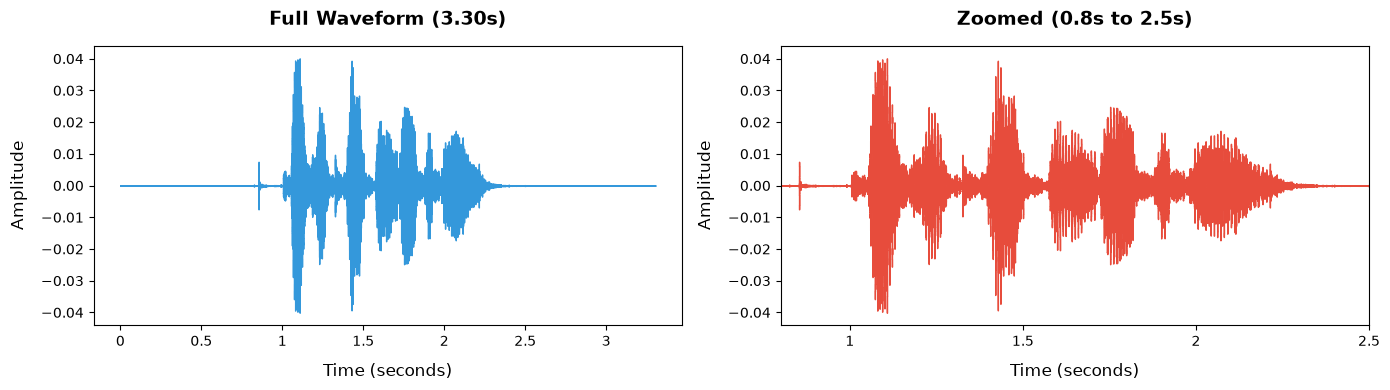

In [2]:
# Grabbing the very first audio file found in the raw directory to perform an EDA (Exploratory Data Analysis)
sample_files = glob.glob(os.path.join(DATA_SOURCE, "**", "*.wav"), recursive=True) #Contains all the filepath of all audio files in the raw directory

if sample_files:
    eda_file_path = sample_files[0] # Grabbing just the first file path out of the list of all file path containing the .wav audio files
    print(f"Visualizing Sample: {os.path.basename(eda_file_path)}") #Printing the filename of the very first file path. The output is a string of the filename
    
    # Load raw audio (using unique variable names to avoid conflicts with custom libraries created for the purpose of this project)
    # Loading the audio file into a Numpy array using librosa.load from a wav file using a sampling rate of 16000Hz 
    # The output of librosa.load is a tuple holding the array and the sampling rate used(22050 Hz is the default used if not specified), the input is the filepath to the audio file
    # We are using the default of librosa.load that forces stereo audio files into mono. The shape of the resulting array is a flat, 1D array where the length equals sample_rate × total duration (seconds). 
    eda_audio_array, eda_sr = librosa.load(eda_file_path, sr=16000)

    # Summary of the Data loaded into the Array using librosa.load 
    total_samples = len(eda_audio_array) # To know the number the number of data points in the array
    duration_seconds = total_samples / eda_sr # Using the sample rate and number of data points to determine the seconds of audio loaded. (Sampling Rate * Seconds = Total Array Item)
    
    # The Audio Math Deduction 
    print("--- DIGITAL AUDIO MATH ---")
    print(f"1. Total Array Items (Samples): {total_samples:,}")
    print(f"2. Sampling Rate (Snapshots per second): {eda_sr:,} Hz")
    print(f"3. Deduced Duration: {total_samples:,} / {eda_sr:,} = {duration_seconds:.2f} seconds\n")
    
    # Plot the Waveforms (Macro vs Micro)
    plt.figure(figsize=(14, 4))
    
    # 1. Full Waveform
    plt.subplot(1, 2, 1)
    librosa.display.waveshow(eda_audio_array, sr=eda_sr, color="#3498db")
    plt.title(f"Full Waveform ({duration_seconds:.2f}s)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Time (seconds)", fontsize=12, labelpad=10)
    plt.ylabel("Amplitude", fontsize=12, labelpad=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    
    # 2. Zoomed Waveform
    plt.subplot(1, 2, 2)
    librosa.display.waveshow(eda_audio_array, sr=eda_sr, color="#e74c3c") # Red for visual distinction
    plt.title("Zoomed (0.8s to 2.5s)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Time (seconds)", fontsize=12, labelpad=10)
    plt.ylabel("Amplitude", fontsize=12, labelpad=10)
    plt.xlim(0.8, 2.5)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    
    plt.tight_layout()
    plt.show()

    # Display the interactive audio player
    display(ipd.Audio(eda_audio_array, rate=eda_sr))
else:
    print("Error: No audio files found. Check your DATA_SOURCE path.")

In [14]:
# Run our custom tool to parse the audio files for labels, extract MFCCs, pad the MFCCs to esnure unformity and save the data
extract_and_serialize_features(DATA_SOURCE, DATA_DESTINATION) #Running the custom function defined previously and saved

Discovered 1440 files. Starting extraction...

--- EXTRACTION CONFIGURATION ---
Sample Rate: 16000 Hz
Base MFCCs (n_mfcc): 20
Total Feature Height (Base + 2 Deltas): 60
Max Pad Length (Time Steps): 125
Augmentations: Active (Original, White Noise, Pitch Shift)
--------------------------------

Processed 100/1440 source files...
Processed 200/1440 source files...
Processed 300/1440 source files...
Processed 400/1440 source files...
Processed 500/1440 source files...
Processed 600/1440 source files...
Processed 700/1440 source files...
Processed 800/1440 source files...
Processed 900/1440 source files...
Processed 1000/1440 source files...
Processed 1100/1440 source files...
Processed 1200/1440 source files...
Processed 1300/1440 source files...
Processed 1400/1440 source files...

--- EXTRACTION COMPLETE ---
Total Augmented Files: 3840
X Shape: (3840, 60, 125)
y Shape: (3840,)
Saved to ..\data\processed


In [15]:
# Load the saved data to prove it worked
X = np.load(os.path.join(DATA_DESTINATION, "X_features.npy"))
y = np.load(os.path.join(DATA_DESTINATION, "y_labels.npy"))

print(f"Verified Final X Shape: {X.shape}")
print(f"Verified Final y Shape: {y.shape}")

Verified Final X Shape: (3840, 60, 125)
Verified Final y Shape: (3840,)


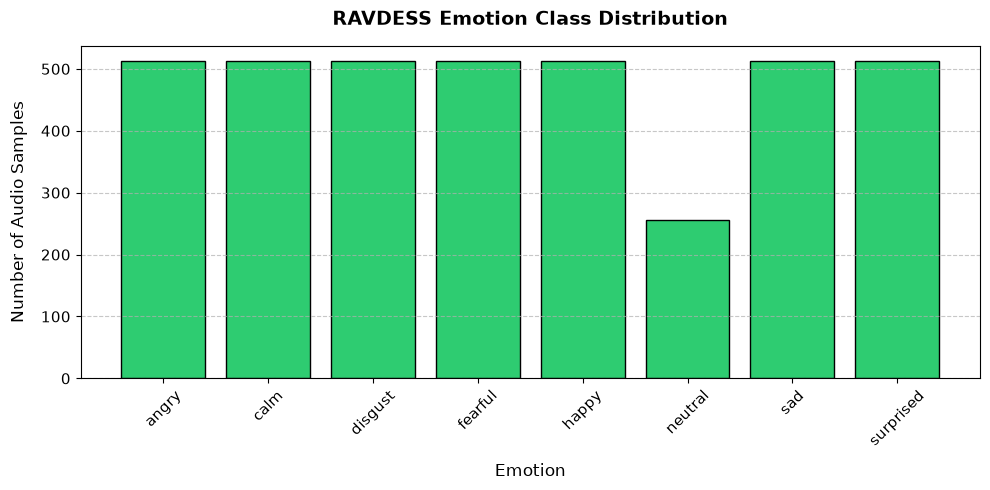

In [ ]:

# Class Distribution of each Emotion
# Count the occurrences of each emotion
classes, counts = np.unique(y, return_counts=True)

# Plot Class Distribution
plt.figure(figsize=(10, 5))
plt.bar(classes, counts, color='#2ecc71', edgecolor='black')
plt.title("RAVDESS Emotion Class Distribution", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Emotion", fontsize=12, labelpad=10)
plt.ylabel("Number of Audio Samples", fontsize=12, labelpad=10)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

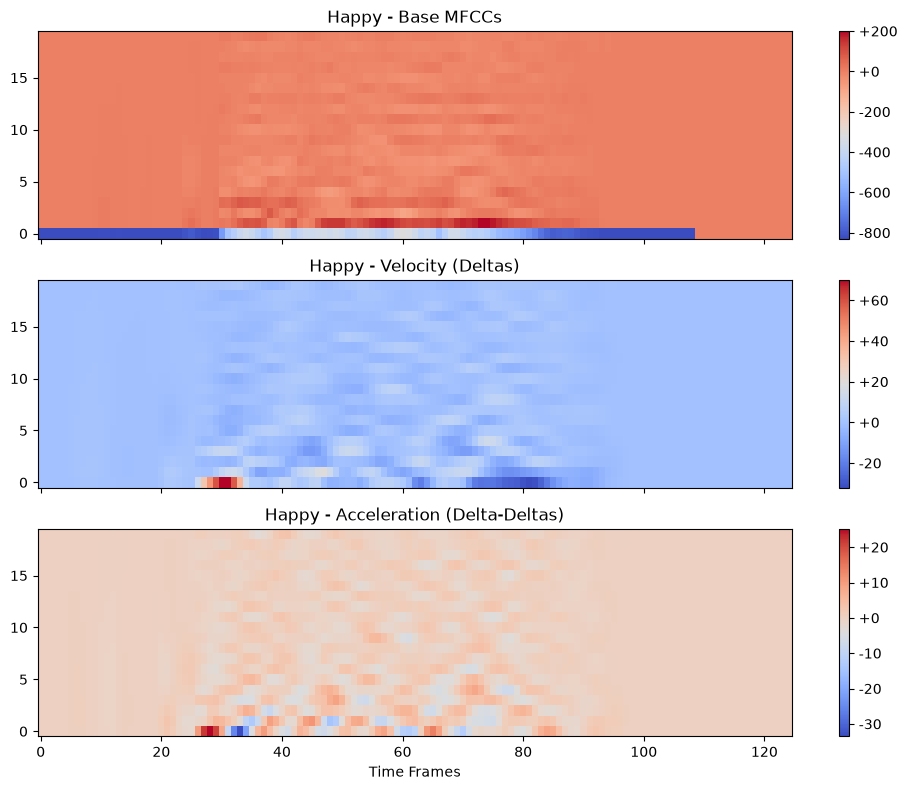

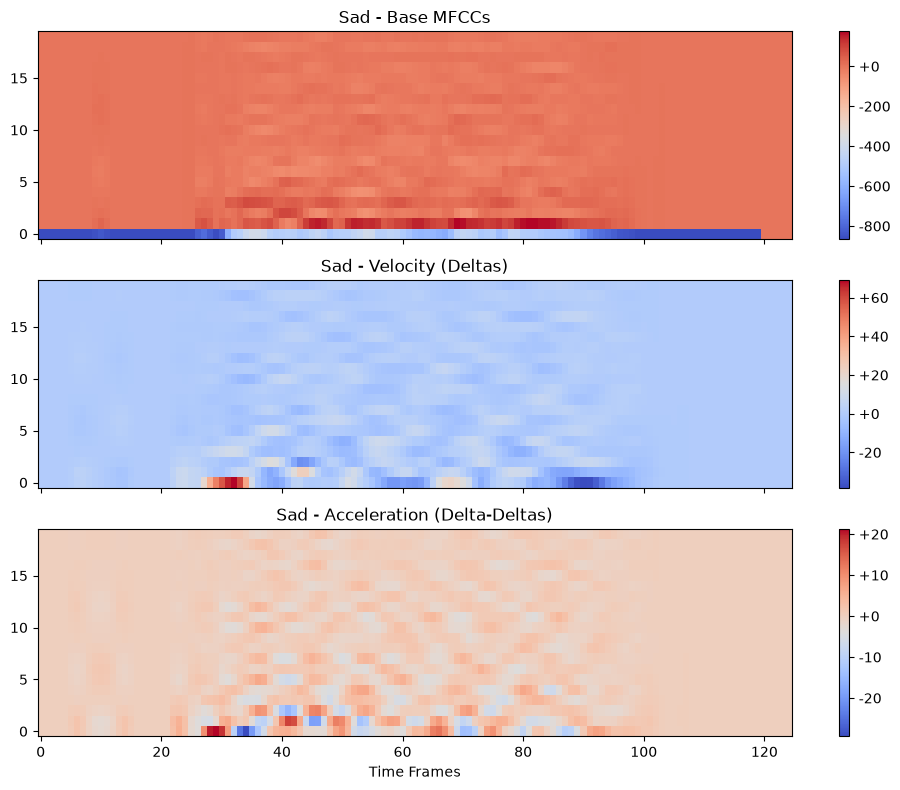

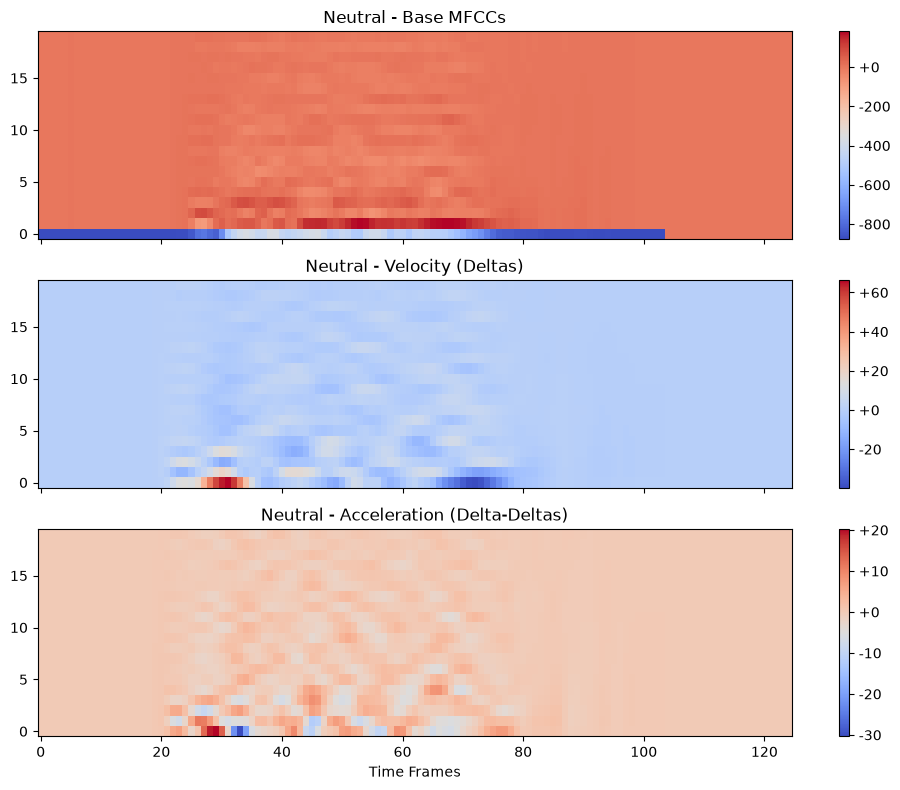

In [6]:

# EDA - Comparative MFCCs to see Visual diffrences in their MFCCs(Happy vs. Sad)
import matplotlib.pyplot as plt
import numpy as np

# 1. Safely grab the FIRST occurrence of each emotion. 
# Because of our data_loader loop, the first appended file is ALWAYS the clean original!
happy_idx = np.where(y == 'happy')[0][0]
sad_idx = np.where(y == 'sad')[0][0]
neutral_idx = np.where(y == 'neutral')[0][0]

def plot_advanced_features(X_data, emotion_title):
    """Plots the 60-row feature matrix split into 3 distinct acoustic subplots."""
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    
    # Base MFCCs (Rows 0-19)
    img1 = axes[0].imshow(X_data[0:20], aspect='auto', origin='lower', cmap='coolwarm')
    axes[0].set_title(f"{emotion_title} - Base MFCCs")
    fig.colorbar(img1, ax=axes[0], format='%+2.0f')
    
    # Velocity Deltas (Rows 20-39)
    img2 = axes[1].imshow(X_data[20:40], aspect='auto', origin='lower', cmap='coolwarm')
    axes[1].set_title(f"{emotion_title} - Velocity (Deltas)")
    fig.colorbar(img2, ax=axes[1], format='%+2.0f')
    
    # Acceleration Deltas (Rows 40-59)
    img3 = axes[2].imshow(X_data[40:60], aspect='auto', origin='lower', cmap='coolwarm')
    axes[2].set_title(f"{emotion_title} - Acceleration (Delta-Deltas)")
    fig.colorbar(img3, ax=axes[2], format='%+2.0f')
    
    plt.xlabel('Time Frames')
    plt.tight_layout()
    plt.show()

# Generate the new visual comparisons
plot_advanced_features(X[happy_idx], "Happy")
plot_advanced_features(X[sad_idx], "Sad")
plot_advanced_features(X[neutral_idx], "Neutral")

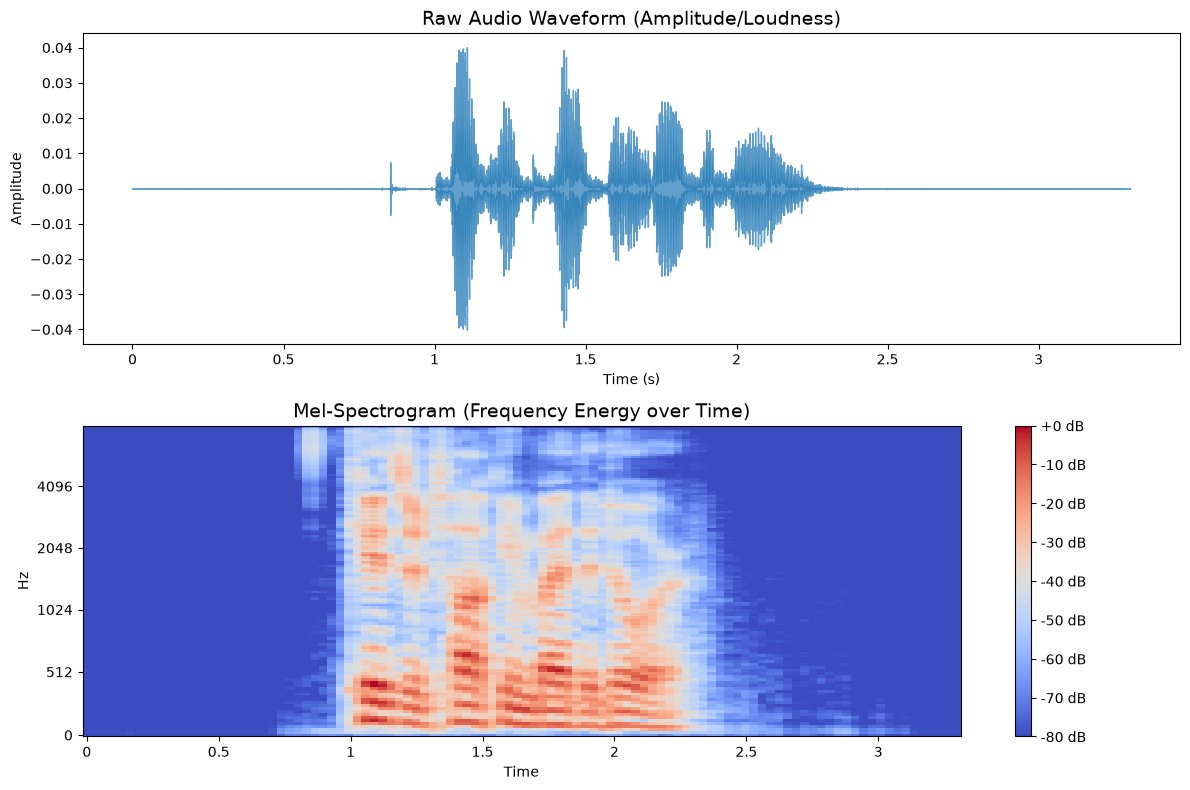

In [7]:

# Grab one sample file from your raw data directory
sample_files_1 = glob.glob(os.path.join(DATA_SOURCE, "**", "*.wav"), recursive=True)

if sample_files_1:
    sample_file = sample_files_1[0] # Grab the first file for demonstration
    y_raw, sr_raw = librosa.load(sample_file, sr=16000)
    
    plt.figure(figsize=(12, 8))
    
    # 1. Plot the Waveform (Amplitude vs. Time)
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(y_raw, sr=sr_raw, alpha=0.7)
    plt.title('Raw Audio Waveform (Amplitude/Loudness)', fontsize=14)
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    
    # 2. Plot the Mel-Spectrogram (Frequency Energy)
    plt.subplot(2, 1, 2)
    mel_spect = librosa.feature.melspectrogram(y=y_raw, sr=sr_raw, n_mels=128)
    mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)
    librosa.display.specshow(mel_spect_db, sr=sr_raw, x_axis='time', y_axis='mel', cmap='coolwarm')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel-Spectrogram (Frequency Energy over Time)', fontsize=14)
    
    plt.tight_layout()
    plt.show()
else:
    print("No audio files found in the specified DATA_SOURCE directory.")

In [13]:
# Create a new cell for Augmentation Audio Playback
if sample_files:
    print("🎧 1. Playing ORIGINAL Audio:")
    display(ipd.Audio(y_raw, rate=sr_raw))
    
    print("\n🎧 2. Playing WHITE NOISE Augmented Audio:")
    # Using the exact same formula from data_loader.py
    noise_amp = 0.005 * np.random.uniform() * np.amax(y_raw)
    noisy_audio = y_raw + noise_amp * np.random.normal(size=y_raw.shape[0])
    display(ipd.Audio(noisy_audio, rate=sr_raw))
    
    print("\n🎧 3. Playing PITCH SHIFTED Augmented Audio (-2 Semitones):")
    # Shifted down to make the effect clearly audible
    pitched_audio = librosa.effects.pitch_shift(y=y_raw, sr=sr_raw, n_steps=-1)
    display(ipd.Audio(pitched_audio, rate=sr_raw))

🎧 1. Playing ORIGINAL Audio:



🎧 2. Playing WHITE NOISE Augmented Audio:



🎧 3. Playing PITCH SHIFTED Augmented Audio (-2 Semitones):
